# Algebraic Model for Entity Resolution

In this notebook we're going to take a closer look at the algebraic model for Entity Resolution introduced by Talburt in 2007.

In [1]:
!test -f ~/requirements.txt && pip install -r ~/requirements.txt

In the algebraic model the only precondition is that the data is presented as a set of entity references. The `matchescu` framework does that by default through its `IdTable`. All that's left to do is extract some entity references and resolve some entities.

In [2]:
import os
from functools import partial

import polars as pl

from matchescu.extraction import Traits
from matchescu.clustering import EquivalenceClassPartitioner
from matchescu.matching.evaluation.datasets import MagellanDataset
from matchescu.matching.matchers import PPJoin
from matchescu.typing import EntityReferenceIdentifier

# extraction traits
abt_buy = Traits().int(["id"]).string(["name", "description"]).currency(["price"])
amz_ggl = Traits().int(["id"]).string(["title", "manufacturer"]).currency(["price"])
beer = Traits().int(["id"]).string(["Beer_Name", "Brew_Factory_Name", "Style"])
dbl_acm = Traits().int(["id", "year"]).string(["title", "authors", "venue"])
dbl_sch = Traits().int(["id", "year"]).string(["title", "authors", "venue"])
fod_zag = (
    Traits().int(["id", "class"]).string(["name", "addr", "city", "phone", "type"])
)
itn_amz = (
    Traits()
    .int(["id"])
    .string(
        [
            "Song_Name",
            "Artist_Name",
            "Album_Name",
            "Genre",
            "CopyRight",
            "Time",
            "Released",
            "Price",
        ]
    )
)
wal_amz = (
    Traits()
    .int(["id"])
    .string(["title", "category", "brand", "modelno"])
    .currency(["price"])
)

Finally, we can put together a comprehensive configuration for the [DeepMatcher benchmark datasets](https://github.com/anhaidgroup/deepmatcher/blob/master/Datasets.md). The intent here is not to create an optimal configuration, but to learn how to approach record linkage from the F-S perspective. So suboptimal configs will do just fine.

In [3]:
DATADIR = os.path.abspath("../../data/magellan")
DATASETS = {
    "abt-buy": (MagellanDataset(os.path.join(DATADIR, "abt-buy")), abt_buy),
    "amazon-google": (MagellanDataset(os.path.join(DATADIR, "amazon-google")), amz_ggl),
    "beer": (MagellanDataset(os.path.join(DATADIR, "beer")), beer),
    "dblp-acm": (MagellanDataset(os.path.join(DATADIR, "dblp-acm")), dbl_acm),
    "dblp-scholar": (MagellanDataset(os.path.join(DATADIR, "dblp-scholar")), dbl_sch),
    "fodors-zagat": (MagellanDataset(os.path.join(DATADIR, "fodors-zagat")), fod_zag),
    "itunes-amazon": (MagellanDataset(os.path.join(DATADIR, "itunes-amazon")), itn_amz),
    "walmart-amazon": (
        MagellanDataset(os.path.join(DATADIR, "walmart-amazon")),
        wal_amz,
    ),
}
DATASET_NAME = "amazon-google"


def ref_id(records, source):
    return EntityReferenceIdentifier(records[0]["id"], source)


for ds_name, (ds, traits) in DATASETS.items():
    ds.load_left(traits, partial(ref_id, source=ds.left_source))
    ds.load_right(traits, partial(ref_id, source=ds.right_source))
    ds.load_splits()

The algebraic model defines ER as an equivalence relation. That means two things:
- ER is going to output a partition
- ER is performed in two steps:
  a) a similarity or match function compares entity references and decides whether they're equivalent (this is a deterministic binary verdict)
  b) equivalent references are clustered together

This is fairly simple to implement once a deterministic matcher is chosen. We're going to implement this using PPJoin.

In [4]:
dataset = DATASETS[DATASET_NAME][0]
matcher = PPJoin(0.5)
matches = matcher.predict(dataset.test_split.comparison_space, dataset.id_table)
print(len(matches))

53


Now that we have the matches, we can use the equivalence class partitioning clusterer to obtain the partition induced by our matcher. The comparison space we provided to the matcher contains all the entity reference IDs that are subjected to ER. The partitioner then constructs a partition over that set of entity reference IDs by using the Union-Find data structure.

We can then compute all sorts of metrics to evaluate the outcome of our task against a clustered ground truth obtained by applying ECP on the pairwise ground truth supplied by the dataset.

In [5]:
from pyresolvemetrics import (
    pair_precision,
    pair_recall,
    pair_comparison_measure,
    cluster_precision,
    cluster_recall,
    cluster_comparison_measure,
    rand_index,
    adjusted_rand_index,
    twi,
)


CLUSTER_METRICS_MAP = {
    "Pair Precision": pair_precision,
    "Pair Recall": pair_recall,
    "Pairwise Comparison": pair_comparison_measure,
    "Cluster Precision": cluster_precision,
    "Cluster Recall": cluster_recall,
    "Cluster Comparison": cluster_comparison_measure,
    "Rand Index": rand_index,
    "Adjusted Rand Index": adjusted_rand_index,
    "Talburt-Wang Index": twi,
}

REF_ID_MAP = {
    ds_name: list(
        ref_id for pair in ds_config[0].test_split.comparison_space for ref_id in pair
    )
    for ds_name, ds_config in DATASETS.items()
}
DATASET_MATCHES_MAP = {}


def match_references(jaccard_threshold, ds_name):
    m = PPJoin(jaccard_threshold)
    ds = DATASETS[ds_name][0]

    res = m.predict(ds.test_split.comparison_space, ds.id_table)
    DATASET_MATCHES_MAP[ds_name] = res  # cache for future use

    return res


def compute_cluster_metrics(jaccard_threshold, ds_name):
    ds = DATASETS[ds_name][0]
    ecp = EquivalenceClassPartitioner(REF_ID_MAP[ds_name])
    gt_clusters = ecp(ds.test_split.ground_truth)
    clusters = ecp(match_references(jaccard_threshold, ds_name))

    result = {"dataset": ds_name, "threshold": jaccard_threshold}
    result.update(
        {
            k: round(float(v(gt_clusters, clusters)), 2)
            for k, v in CLUSTER_METRICS_MAP.items()
        }
    )
    return result


compute_cluster_metrics(0.34, DATASET_NAME)

{'dataset': 'amazon-google',
 'threshold': 0.34,
 'Pair Precision': 0.31,
 'Pair Recall': 0.48,
 'Pairwise Comparison': 0.37,
 'Cluster Precision': 0.8,
 'Cluster Recall': 0.8,
 'Cluster Comparison': 0.8,
 'Rand Index': 1.0,
 'Adjusted Rand Index': 0.37,
 'Talburt-Wang Index': 0.86}

Determining the best score using PPJoin is a simple matter of trying various Jaccard threshold values, plotting the results and picking the best fit.

In [6]:
import numpy as np


thresholds = list(map(float, np.arange(0, 1, 0.05)))
evaluation_results = list(
    map(partial(compute_cluster_metrics, ds_name=DATASET_NAME), thresholds)
)
ppjoin_report = pl.DataFrame(evaluation_results)

display(ppjoin_report)

dataset,threshold,Pair Precision,Pair Recall,Pairwise Comparison,Cluster Precision,Cluster Recall,Cluster Comparison,Rand Index,Adjusted Rand Index,Talburt-Wang Index
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""amazon-google""",0.0,0.0,1.0,0.0,0.29,0.05,0.09,0.71,0.0,0.19
"""amazon-google""",0.05,0.0,1.0,0.0,0.31,0.06,0.1,0.71,0.0,0.19
"""amazon-google""",0.1,0.0,0.99,0.0,0.48,0.13,0.21,0.84,0.0,0.27
"""amazon-google""",0.15,0.0,0.98,0.0,0.65,0.28,0.39,0.92,0.0,0.42
"""amazon-google""",0.2,0.01,0.92,0.03,0.74,0.44,0.56,0.99,0.02,0.58
…,…,…,…,…,…,…,…,…,…,…
"""amazon-google""",0.75,0.0,0.0,0.0,0.75,0.86,0.8,1.0,0.0,0.87
"""amazon-google""",0.8,0.0,0.0,0.0,0.75,0.86,0.8,1.0,0.0,0.87
"""amazon-google""",0.85,0.0,0.0,0.0,0.75,0.86,0.8,1.0,0.0,0.87


Next, let's plot the results contained in our newly created report. In order to do that we'll just implement a couple of helper functions that we're going to use later, too.

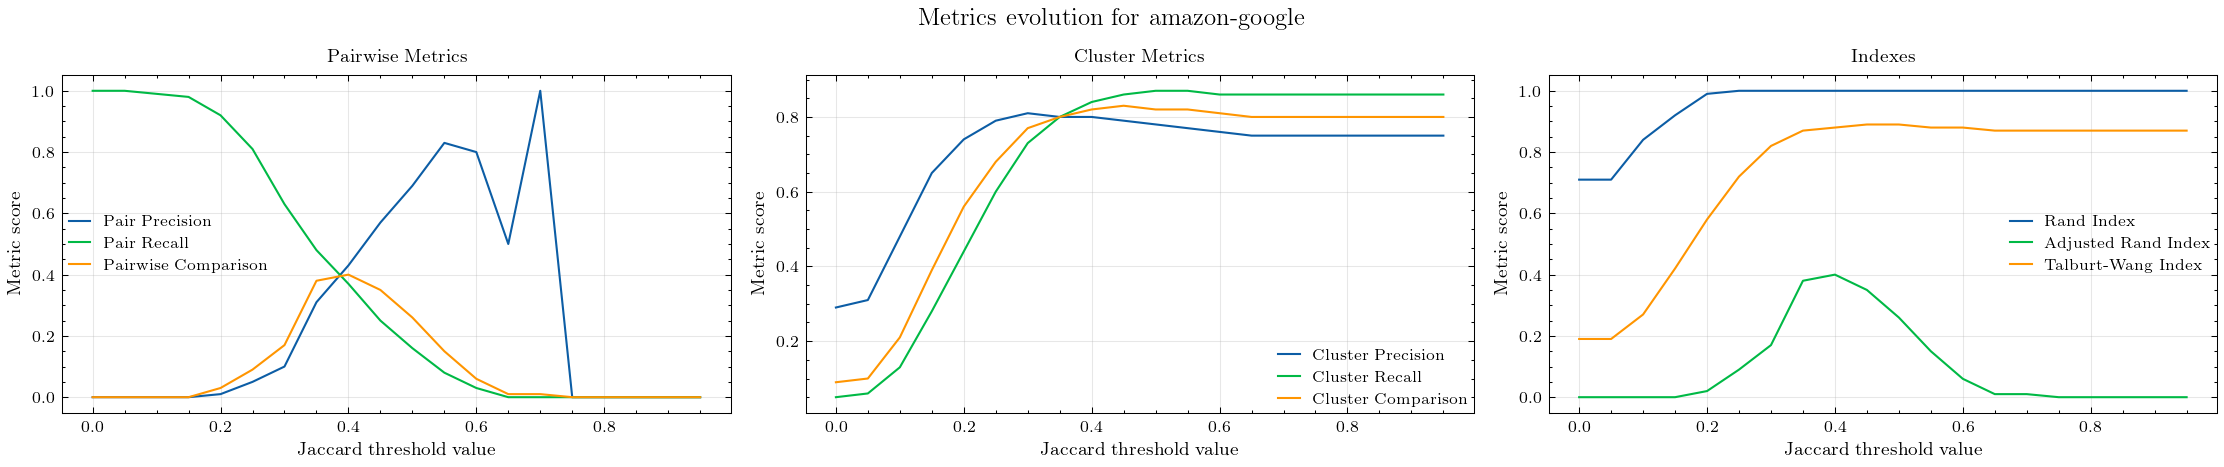

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots


sns.reset_orig()
PLOT_DEFAULTS = {
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,  # on-screen; export uses savefig dpi below
    "savefig.dpi": 300,  # >=300 dpi on export
}
plt.rcParams.update(PLOT_DEFAULTS)
plt.style.use(["science"])


def _metric_vs_threshold_evolution(df, title, metrics, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    else:
        fig = ax.figure

    ax.set_xlabel("Jaccard threshold value")
    ax.set_ylabel("Metric score")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    for metric in metrics:
        sns.lineplot(df, x="threshold", y=metric, label=metric, ax=ax)

    ax.legend(
        borderaxespad=0.0,
        frameon=False,
        handlelength=1.4,
        fontsize="small",
    )
    fig.tight_layout()

    return fig


def side_by_side_metrics_plots(
    report_df, ds_name, metrics_spec, fig_col_count=3, figsize=(15, 3)
):
    fig, axes = plt.subplots(1, fig_col_count, figsize=figsize)

    if fig_col_count == 1:
        axes = [axes]

    df = report_df.filter(pl.col("dataset") == ds_name)
    for i, ((title, metrics), ax) in enumerate(zip(metrics_spec.items(), axes)):
        _metric_vs_threshold_evolution(df, title, metrics, ax=ax)

        snake_case_title = title.lower().replace(" ", "_")
        snake_case_ds_name = ds_name.lower().replace(" ", "_")
        file_name = f"{snake_case_ds_name}-{snake_case_title}"
        _save_figure(file_name, ax)

    fig.suptitle(f"Metrics evolution for {ds_name}", fontsize=12, y=1.05)
    plt.show()


def _save_figure(file_name, ax):
    DIR_NAME = "figures/algebraic-exploration"
    os.makedirs(DIR_NAME, exist_ok=True)
    fpath = f"{DIR_NAME}/{file_name}.png"

    fig = ax.figure
    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(
        fig.dpi_scale_trans.inverted()
    )
    fig.savefig(fpath, bbox_inches=extent.expanded(1.02, 1.05))


side_by_side_metrics_plots(
    ppjoin_report,
    DATASET_NAME,
    {
        "Pairwise Metrics": ["Pair Precision", "Pair Recall", "Pairwise Comparison"],
        "Cluster Metrics": [
            "Cluster Precision",
            "Cluster Recall",
            "Cluster Comparison",
        ],
        "Indexes": ["Rand Index", "Adjusted Rand Index", "Talburt-Wang Index"],
    },
)

Plots look pretty, so let's make some more. Let's see the best Jaccard thresholds across all datasets.

In [8]:
evaluation_results = []
for ds_name in DATASETS:
    evaluate_dataset = partial(compute_cluster_metrics, ds_name=ds_name)
    evaluation_results.extend(list(map(evaluate_dataset, thresholds)))
ppjoin_report = pl.DataFrame(evaluation_results)

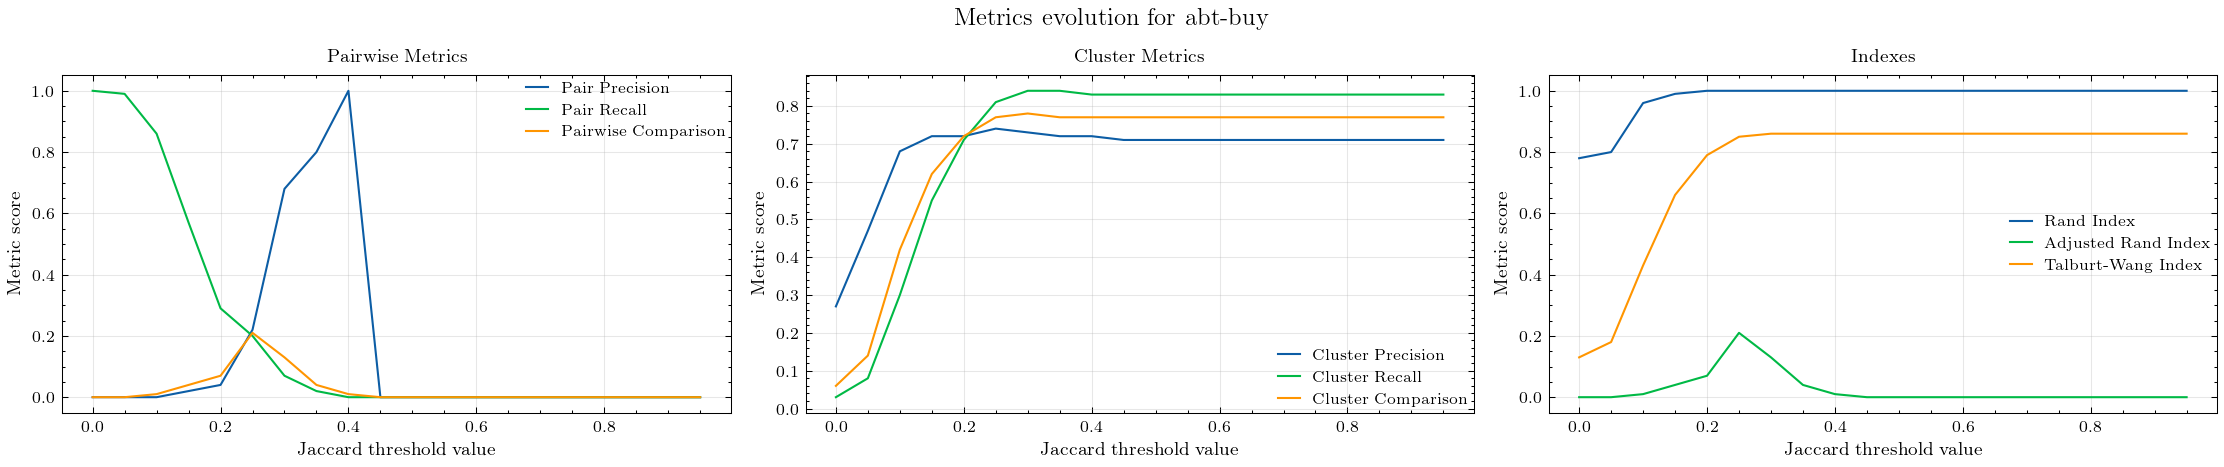

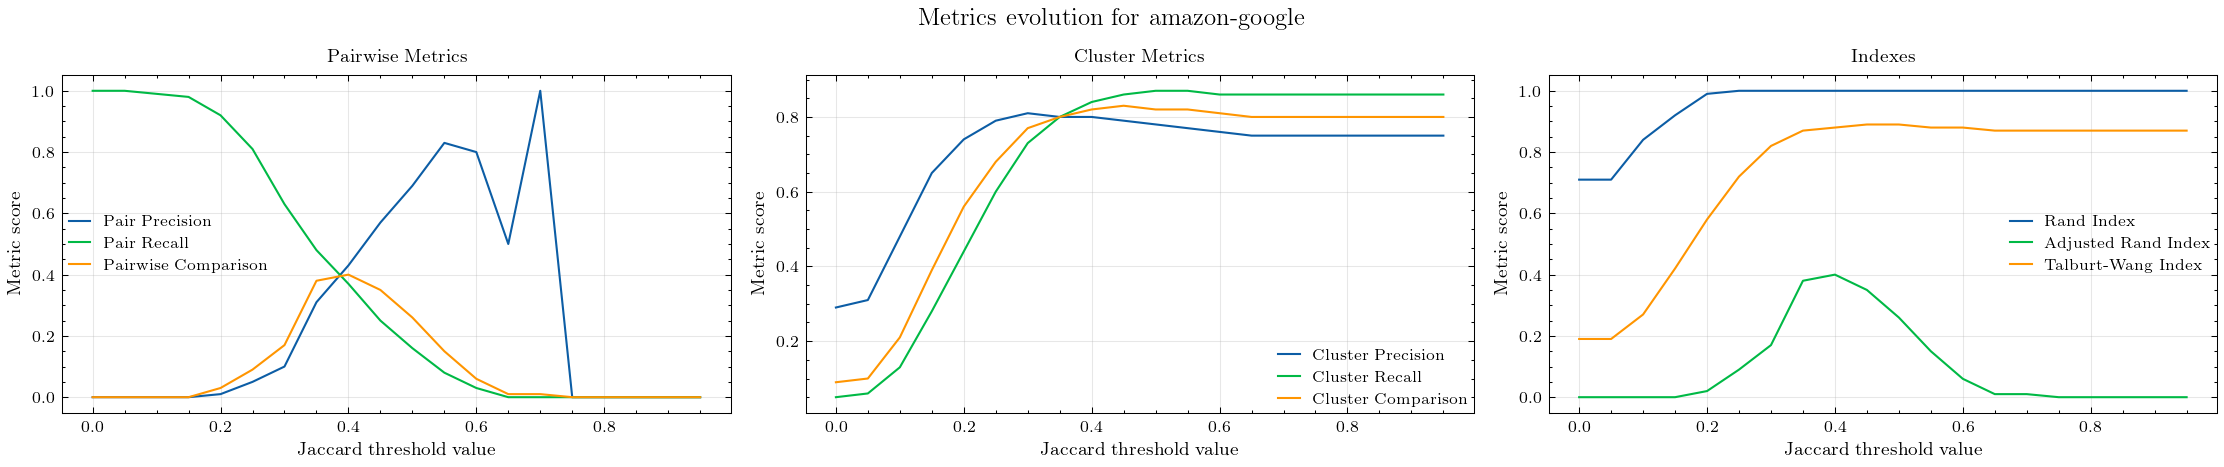

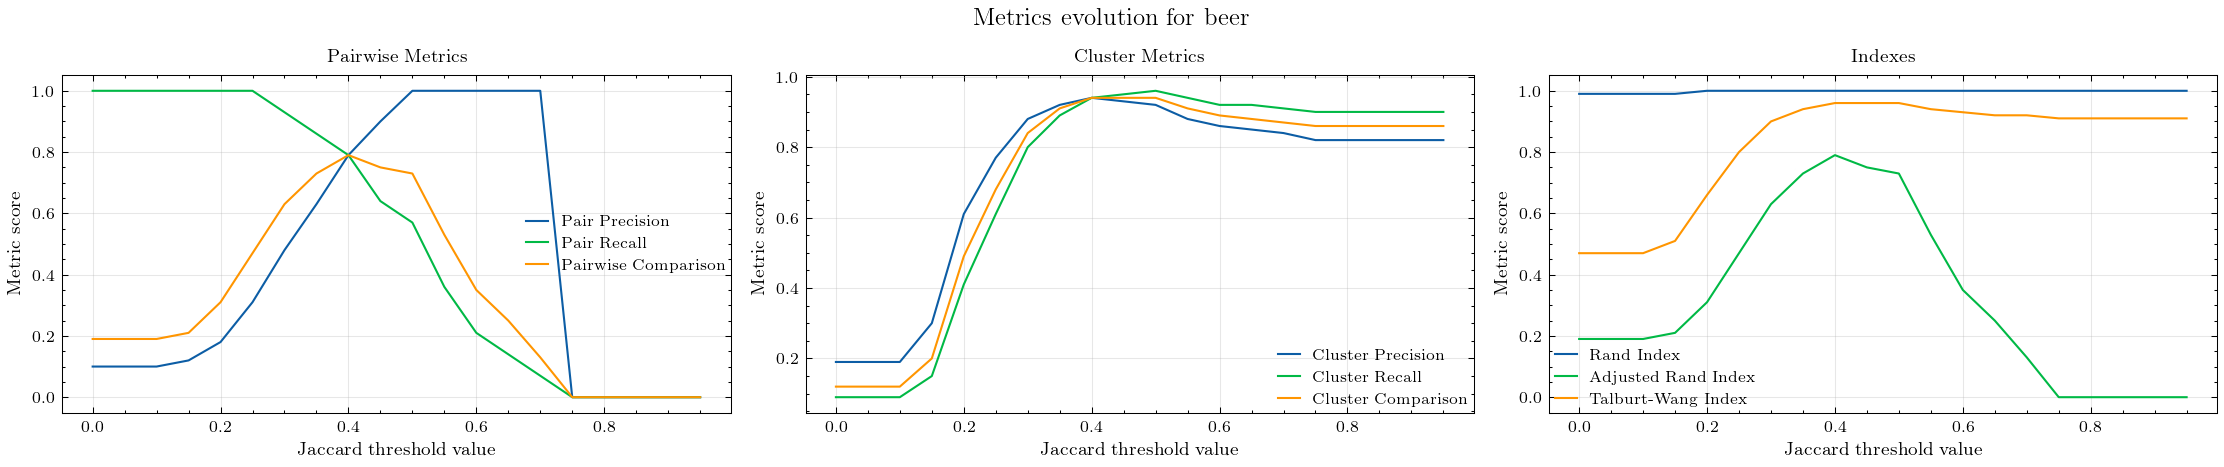

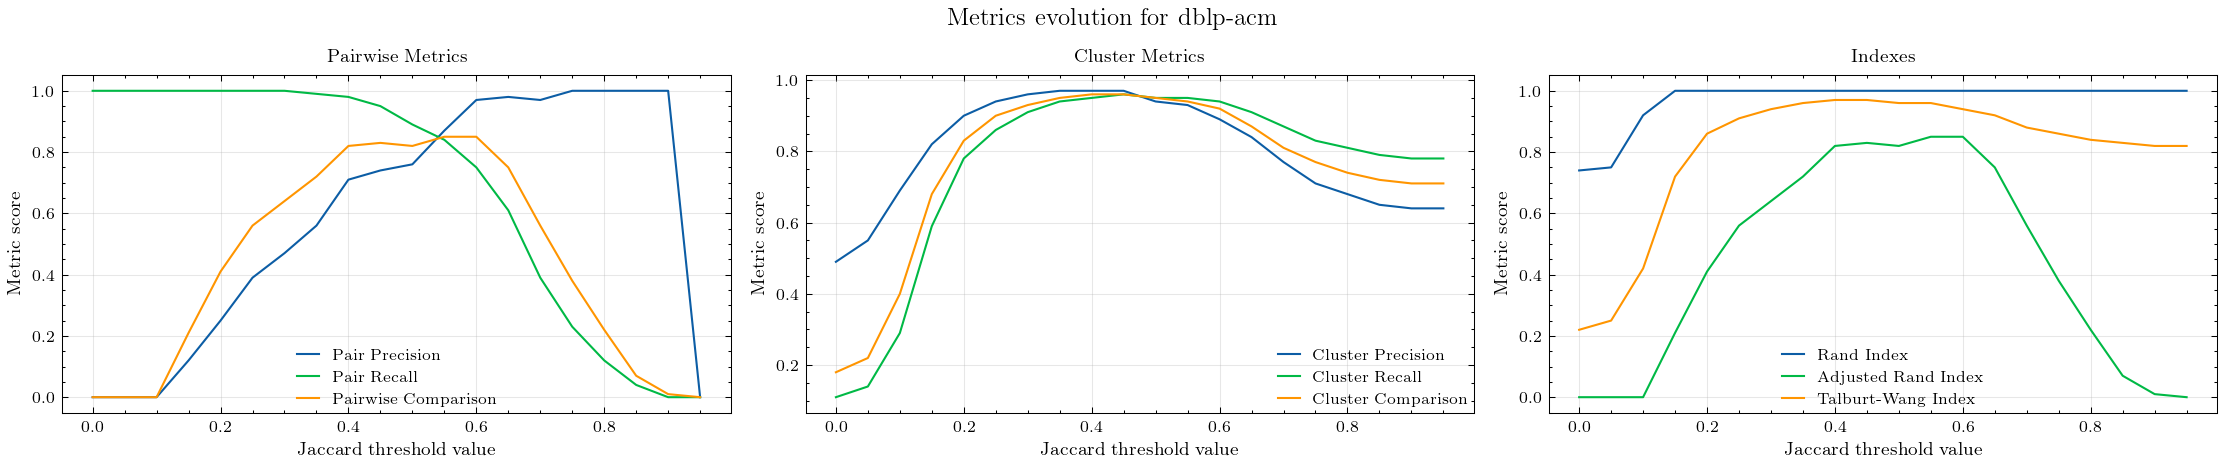

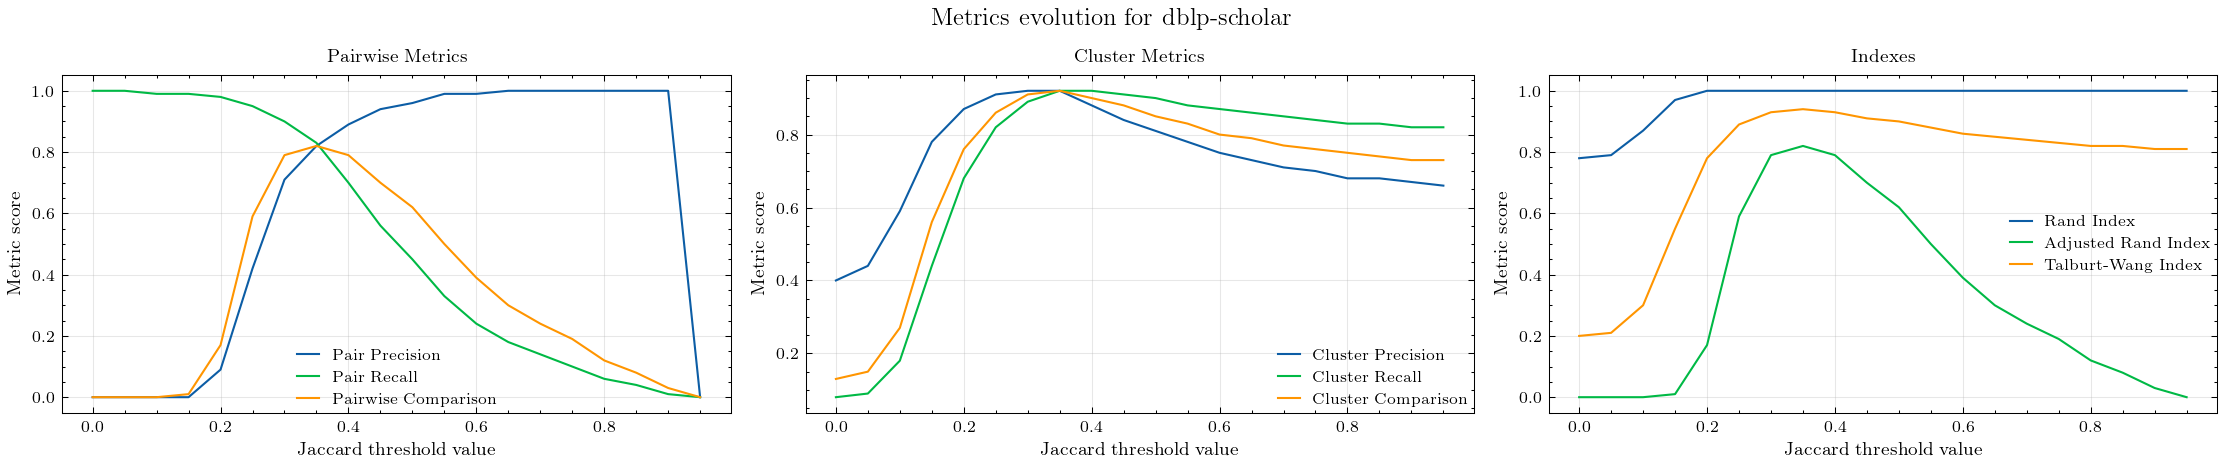

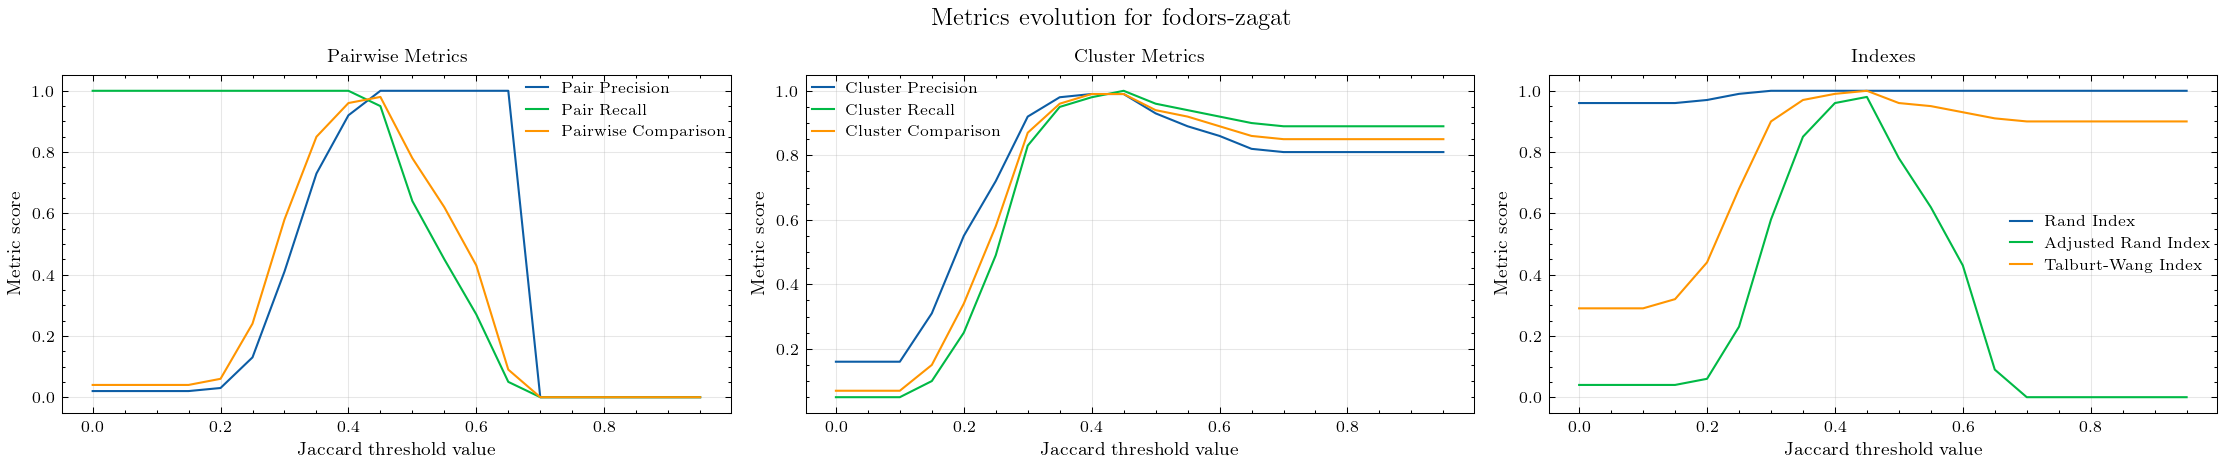

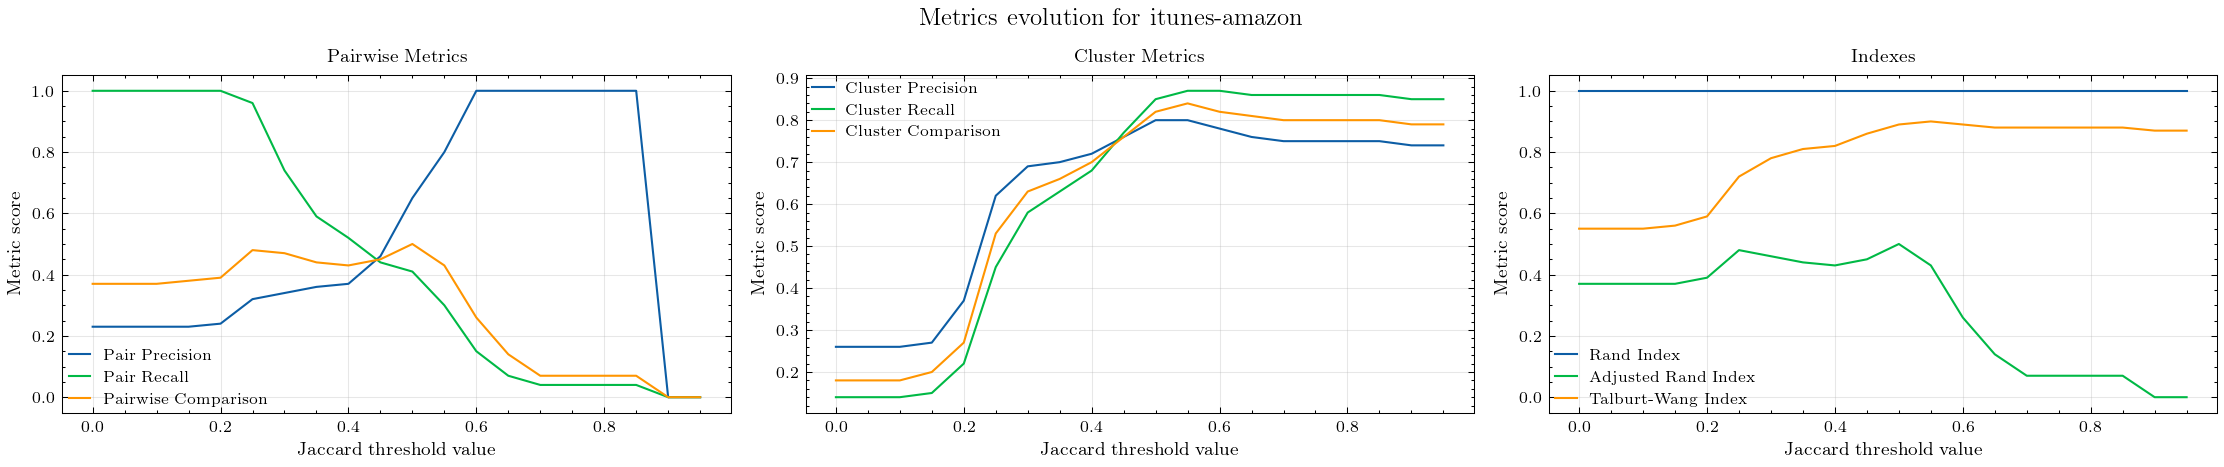

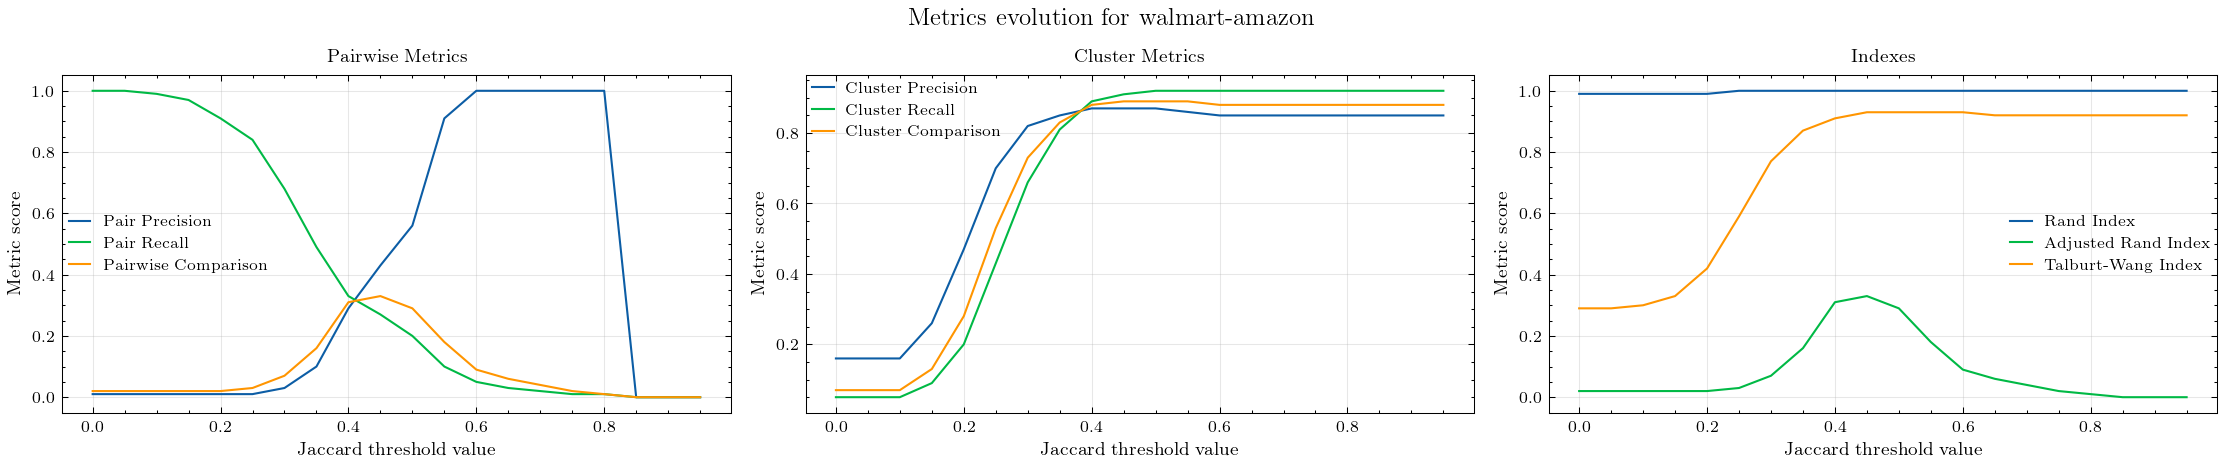

In [9]:
for ds_name in DATASETS:
    side_by_side_metrics_plots(
        ppjoin_report,
        ds_name,
        {
            "Pairwise Metrics": [
                "Pair Precision",
                "Pair Recall",
                "Pairwise Comparison",
            ],
            "Cluster Metrics": [
                "Cluster Precision",
                "Cluster Recall",
                "Cluster Comparison",
            ],
            "Indexes": ["Rand Index", "Adjusted Rand Index", "Talburt-Wang Index"],
        },
    )

Naturally, you'd want the configuration that leads to the best clusters and the best pairwise performance. In our case, we'd choose the Jaccard threshold with the highest pairwise scores and Talburt-Wang index. Notice how the curve of the pairwise comparison measure is identical to the curve described by the adjusted Rand index.

One thing that we might wonder about is how the matcher's performance relates to this. So let's plot that, too. First, let's see how we can compute precision, recall and F1 to evaluate the matcher.

In [13]:
from pyresolvemetrics import precision, recall, f1


PROBABILISTIC_METRICS = {
    "Precision": precision,
    "Recall": recall,
    "F$_1$ Score": f1,
}


def compute_prob_metrics(jaccard_threshold, ds_name):
    ds = DATASETS[ds_name][0]

    matching_references = DATASET_MATCHES_MAP.get(
        ds_name, match_references(jaccard_threshold, ds_name)
    )

    result = {"dataset": ds_name, "threshold": jaccard_threshold}
    result.update(
        {
            k: round(float(v(ds.test_split.ground_truth, matching_references)), 2)
            for k, v in PROBABILISTIC_METRICS.items()
        }
    )
    return result


compute_prob_metrics(0.4, DATASET_NAME)

{'dataset': 'amazon-google',
 'threshold': 0.4,
 'Precision': 0.58,
 'Recall': 0.37,
 'F$_1$ Score': 0.45}

Right. Let's compute the matcher scores across all thresholds and all datasets now.

In [ ]:
matcher_results = []
for ds_name in DATASETS:
    evaluate_dataset = partial(compute_prob_metrics, ds_name=ds_name)
    matcher_results.extend(list(map(evaluate_dataset, thresholds)))
matcher_report = pl.DataFrame(matcher_results)
display(matcher_report)

Finally, let's see whether there's some similarity between matching and clustering metrics.

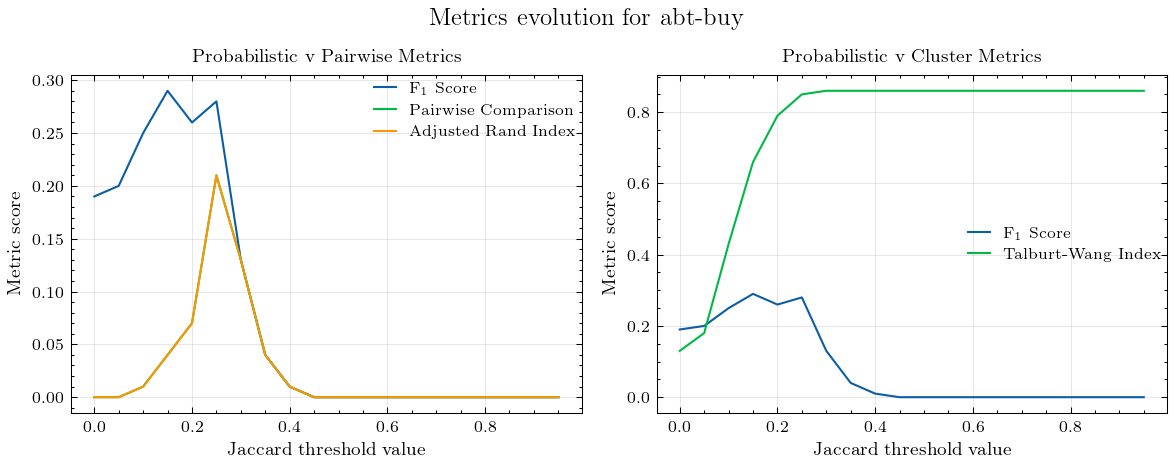

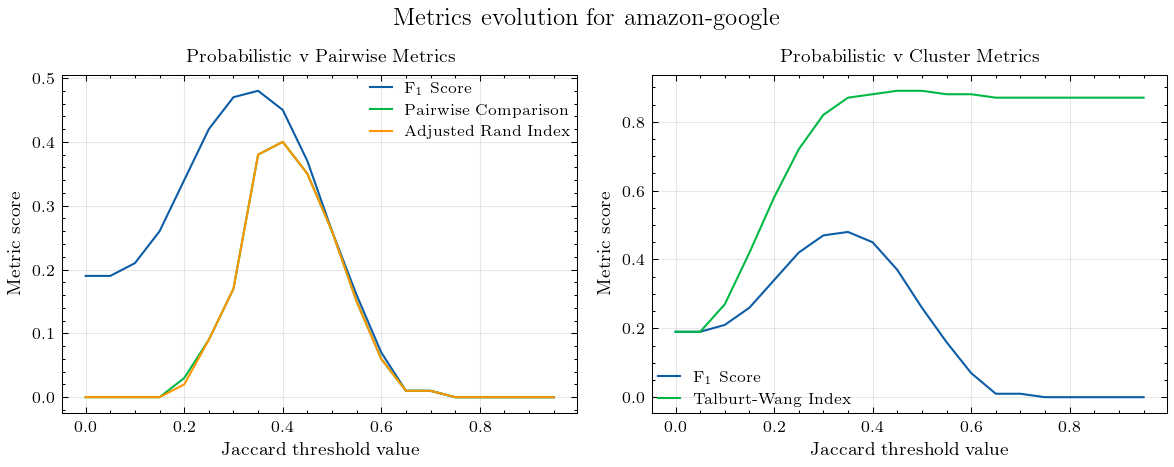

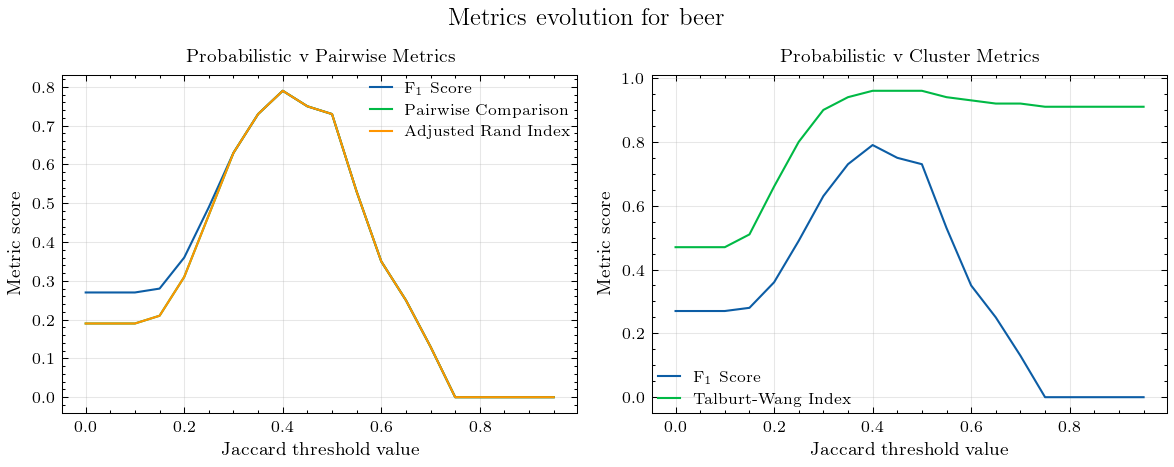

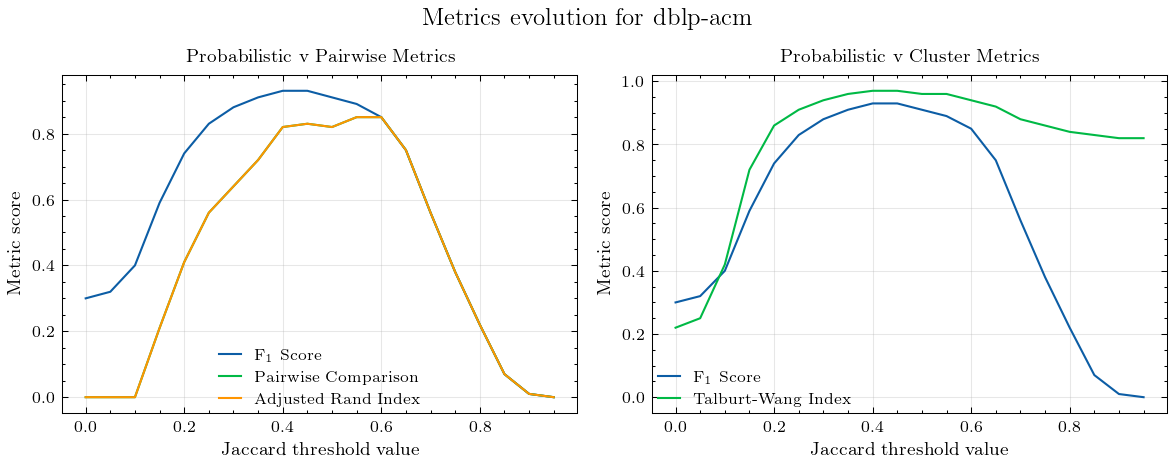

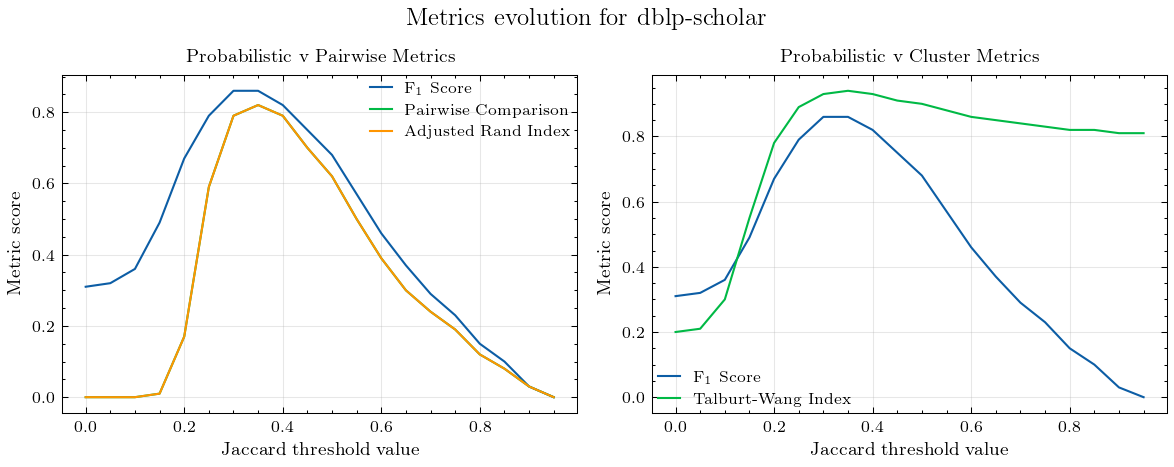

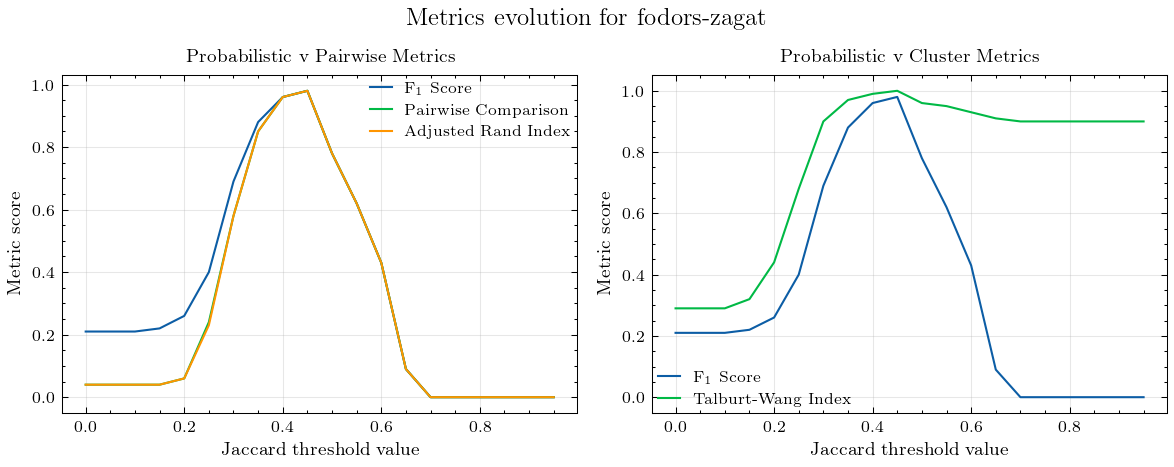

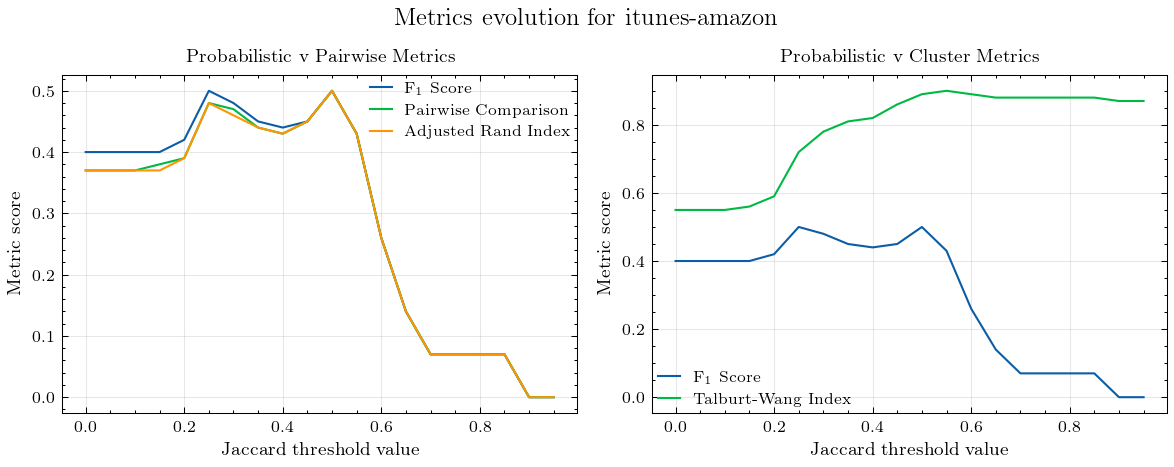

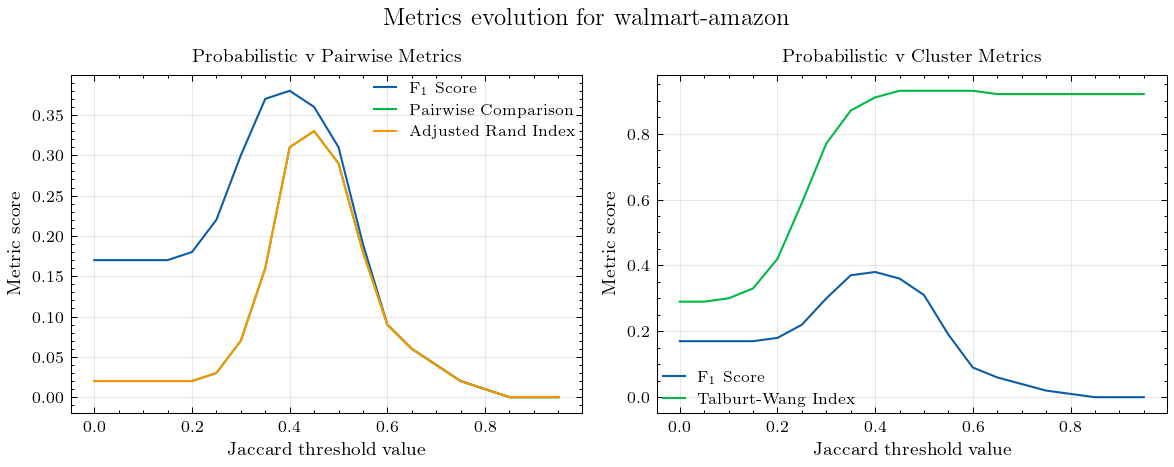

In [12]:
final_report = ppjoin_report.join(
    matcher_report, on=["dataset", "threshold"], how="inner"
)

for ds_name in DATASETS:
    side_by_side_metrics_plots(
        final_report,
        ds_name,
        {
            "Probabilistic v Pairwise Metrics": [
                "F$_1$ Score",
                "Pairwise Comparison",
                "Adjusted Rand Index",
            ],
            "Probabilistic v Cluster Metrics": [
                "F$_1$ Score",
                "Cluster Comparison",
                "Talburt-Wang Index",
            ],
        },
        fig_col_count=2,
        figsize=(8, 3),
    )

Now that we've computed the optimal Jaccard thresholds across all datasets we may use them in our matcher's configuration.
Since we're evaluating partitions, our evaluation inspires more confidence because we're comparing outputs specified in a more complete way. On the other hand, notice that the configuration is completely external to the ER task. We might be using another matching model and finding the optimum parameters for it.
Luckily, using the equivalence class partitioning approach, we can see that probabilistic metrics (precision, recall, and F$_1$ score) closely match pairwise cluster metrics. We can also see that the curve of the Adjusted Rand Index is closely related to that of the Pairwise Comparison measure and the F$_1$ score.

In conclusion, the algebraic model allows evaluating the quality of ER more wholly. Ideally, it also allows selecting and configuring a matcher of choice which can then be used transparently used to cluster items. The latter depends entirely on the clustering implementation. Remember, we're under the terms of the algebraic model only as long as the output of the ER task is a partition over an input set of entity references.